# SSH model with the Liouville Class

### Author : Mathieu Desmarais (python version of the mathematica code of Eric Bitner)
#### Date: 08-06-2026

The goal is to rewrite in python this code that extact third-order nonlinear optical response in the Liouville Space. The model is the SSH model.
This code will be use for starting point for the Spin-Orbite Model for the CuGeO3. 


### packages and modules import

In [13]:
from LiouvilleSpectroscopy import LiouvilleSpectroscopySolver
from LiouvilleSpectroscopy import SpectroscopyPlotter
import numpy as np
import matplotlib.pyplot as plt
import time

### Model function related

In [14]:
def build_raw_tensors(k_array, t1,t2):
    N = len(k_array)
    d = 2 # ou 3, 4, etc.
    
    H_raw = np.zeros((N, d, d), dtype=complex)
    H_raw[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_raw[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)

    J_raw = np.zeros((N, d, d), dtype=complex)
    J_raw[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_raw[:, 1, 0] =  1j * t2 * np.exp(1j * k_array)
    
    # Tu retournes les matrices brutes. PAS de diagonalisation ici !
    return H_raw, J_raw


#### Building Hamiltonian


In [15]:
TOTAL_KPOINTS = 100
k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)
dk = k_array[1] - k_array[0]


w_list = np.linspace(0.5, 1.5, 100) 
tau2_test = 3.0  # Updated according to your file
    
params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}

t1_topo, t2_topo = params_topo["t1"], params_topo["t2"]
t1_triv, t2_triv = params_triv["t1"], params_triv["t2"]


H_topo,J_raw_topo= build_raw_tensors(k_array, t1_topo,t2_topo)

H_triv,J_raw_triv= build_raw_tensors(k_array, t1_triv,t2_triv)



In [16]:
start = time.time()

# 1. Tu instancies le solveur avec tes paramètres physiques
solveur = LiouvilleSpectroscopySolver(params_topo)
print(f"Call of the class finish in  {time.time() - start:.4f}s")
# 2. Tu injectes tes tenseurs NumPy générés en amont avec QuTiP



start = time.time()
solveur.feed_model(H_triv, J_raw_topo)
print(f"feed_model finish in  {time.time() - start:.4f}s")
# 3. Tu ajoutes tes opérateurs de dissipation de Lindblad (ex: relaxation de bande)
# Le solveur sait qu'il s'agit de tenseurs complets sur l'axe k
c_ops = [(solveur.J_minus, 0.05)] 
solveur.set_dissipation(c_ops)

start = time.time()
# 4. Tu extrais l'ensemble des spectres d'un seul coup
spectres = solveur.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)
print(f"generate_2D_spectra finish in  {time.time() - start:.4f}s")
# Tes données sont prêtes pour ton visualiseur !
S3_pure_rephasing_topo= spectres["rephasing"]
S3_pure_unrephasing_topo = spectres["unrephasing"]


# 1. Tu instancies le solveur avec tes paramètres physiques
solveur = LiouvilleSpectroscopySolver(params_triv)

# 2. Tu injectes tes tenseurs NumPy générés en amont avec QuTiP
solveur.feed_model(H_triv, J_raw_triv)

# 3. Tu ajoutes tes opérateurs de dissipation de Lindblad (ex: relaxation de bande)
# Le solveur sait qu'il s'agit de tenseurs complets sur l'axe k
c_ops = [(solveur.J_minus, 0.05)] 
solveur.set_dissipation(c_ops)

# 4. Tu extrais l'ensemble des spectres d'un seul coup
spectres = solveur.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)

# Tes données sont prêtes pour ton visualiseur !
S3_pure_rephasing_triv= spectres["rephasing"]
S3_pure_unrephasing_triv = spectres["unrephasing"]

Call of the class finish in  0.0002s
feed_model finish in  0.0007s
generate_2D_spectra finish in  35.7600s


#### Spectrum


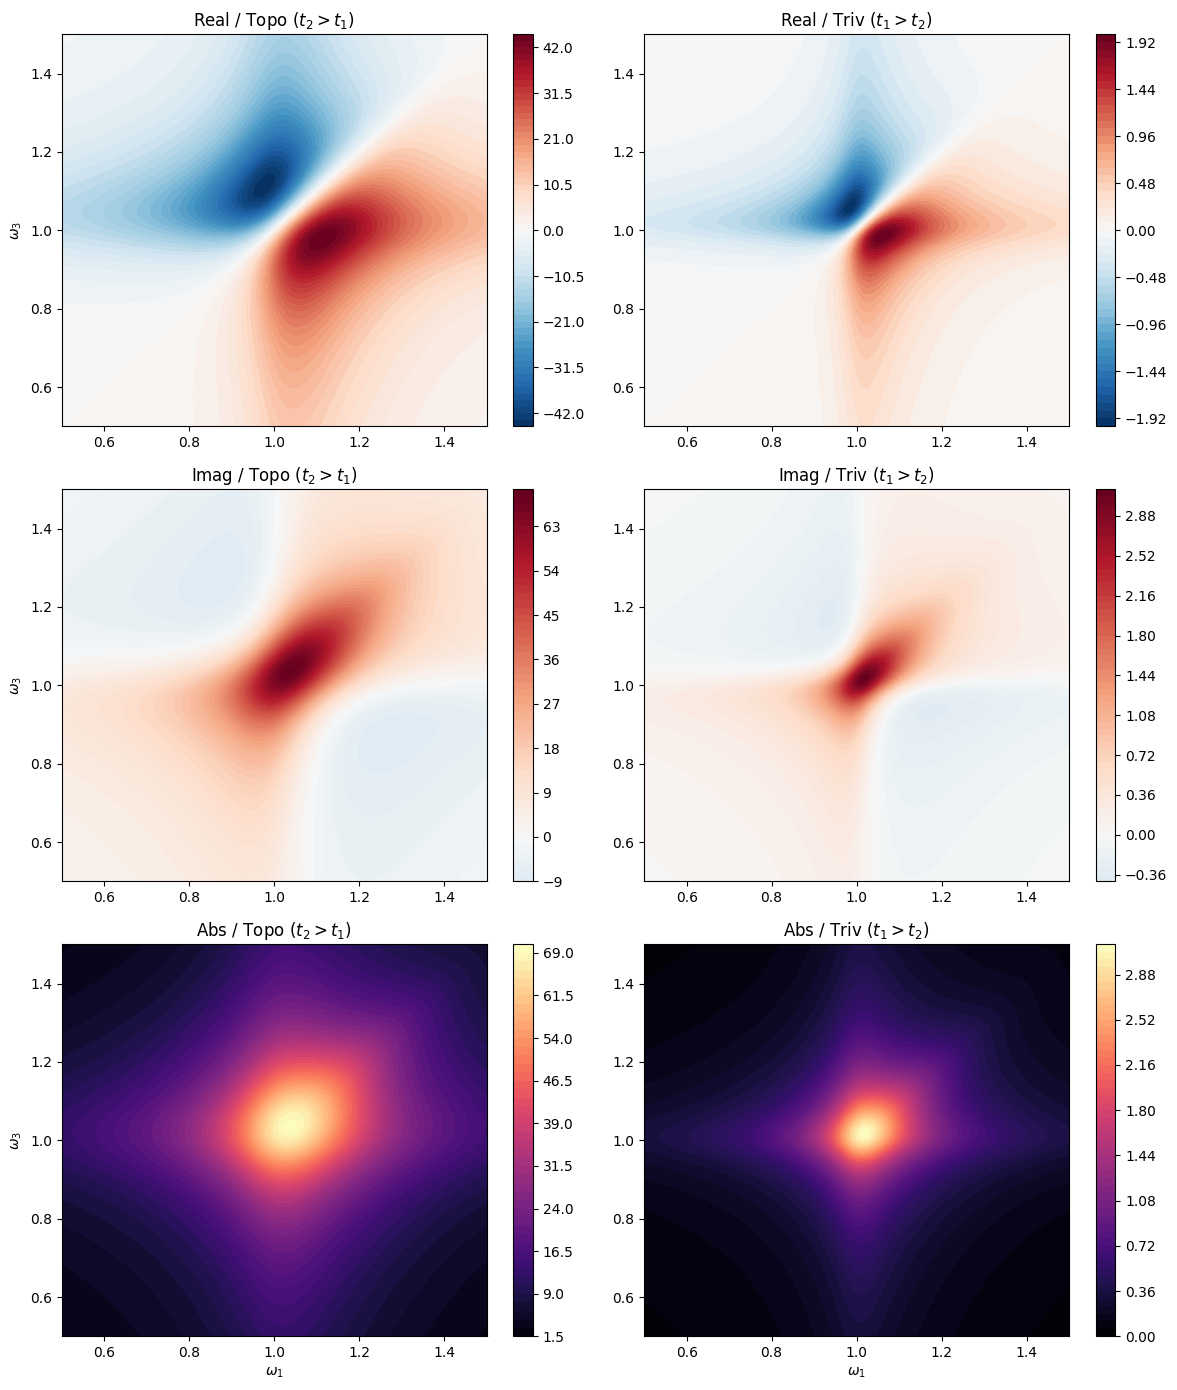

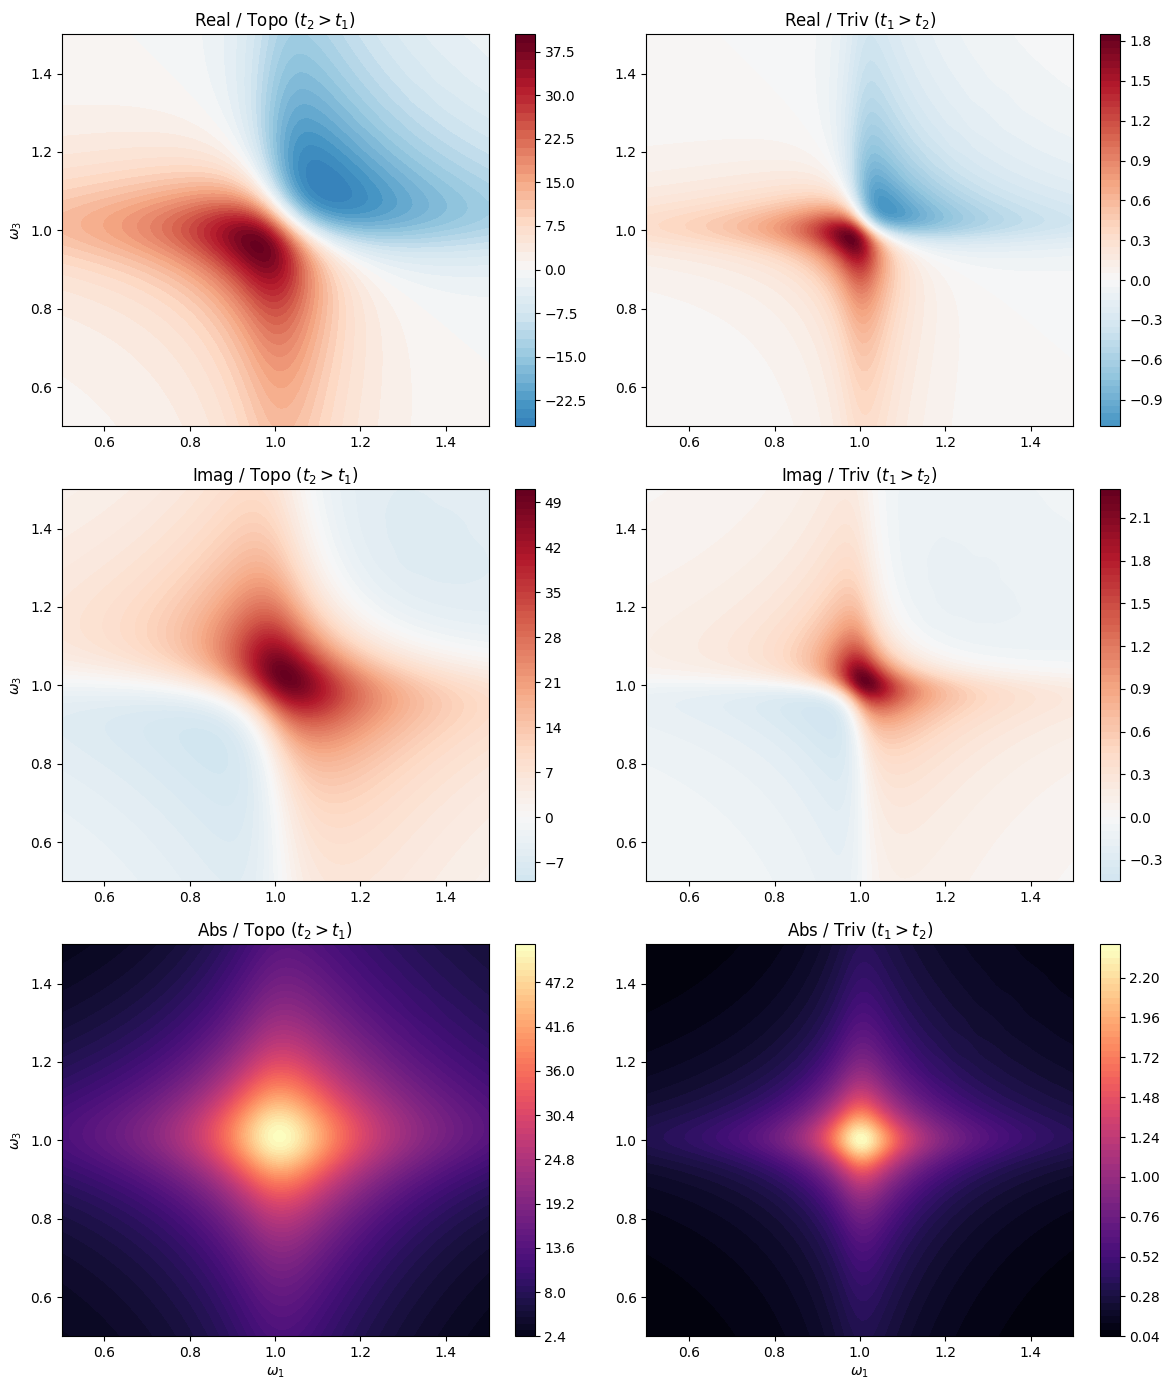

In [17]:
Spec = SpectroscopyPlotter(w_list)


Spec.plot_spectrum(S3_pure_rephasing_topo,S3_pure_rephasing_triv)

Spec.plot_spectrum(S3_pure_unrephasing_topo,S3_pure_unrephasing_triv)


#### Random Functions